Ignoring fixed y limits to fulfill fixed data aspect with adjustable data limits.


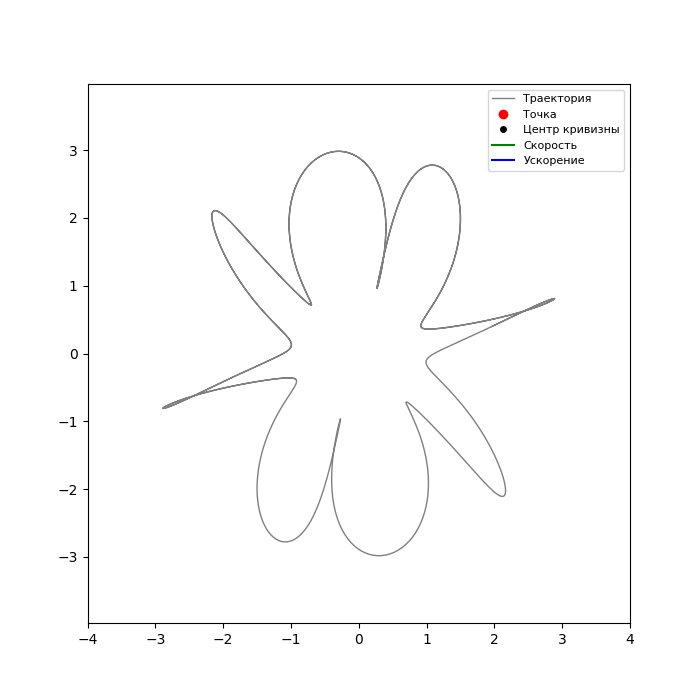

ERROR:tornado.application:Exception in callback <bound method TimerBase._on_timer of <matplotlib.backends.backend_webagg_core.TimerTornado object at 0x7285b3300080>>
Traceback (most recent call last):
  File "/home/roman/Progects/.venv/lib/python3.12/site-packages/tornado/ioloop.py", line 945, in _run
    val = self.callback()
          ^^^^^^^^^^^^^^^
  File "/home/roman/Progects/.venv/lib/python3.12/site-packages/matplotlib/backend_bases.py", line 1152, in _on_timer
    ret = func(*args, **kwargs)
          ^^^^^^^^^^^^^^^^^^^^^
  File "/home/roman/Progects/.venv/lib/python3.12/site-packages/matplotlib/animation.py", line 1450, in _step
    still_going = super()._step(*args)
                  ^^^^^^^^^^^^^^^^^^^^
  File "/home/roman/Progects/.venv/lib/python3.12/site-packages/matplotlib/animation.py", line 1138, in _step
    self._draw_next_frame(framedata, self._blit)
  File "/home/roman/Progects/.venv/lib/python3.12/site-packages/matplotlib/animation.py", line 1157, in _draw_next_f

In [24]:
%matplotlib widget

import numpy as np
import matplotlib.pyplot as plt
from matplotlib.animation import FuncAnimation
import sympy as sp

# Функция поворота координат для отрисовки "наконечника" стрелки
def Rot2D(X, Y, phi):
    X_new = X * np.cos(phi) - Y * np.sin(phi)
    Y_new = X * np.sin(phi) + Y * np.cos(phi)
    return X_new, Y_new

t = sp.Symbol('t')

# Задаем полярные координаты по вашему варианту
r = 2 + sp.sin(8*t)
phi_sym = t + 0.2 * sp.cos(6*t)

# Переводим в декартовы координаты (x = r*cos(phi), y = r*sin(phi))
x = r * sp.cos(phi_sym)
y = r * sp.sin(phi_sym)

# Первая производная - Скорость (Vx, Vy)
Vx = sp.diff(x, t)
Vy = sp.diff(y, t)

# Вторая производная - Ускорение (Wx, Wy)
Wx = sp.diff(Vx, t)
Wy = sp.diff(Vy, t)

# Превращаем символьные формулы в быстрые функции NumPy
F_x = sp.lambdify(t, x, 'numpy')
F_y = sp.lambdify(t, y, 'numpy')
F_Vx = sp.lambdify(t, Vx, 'numpy')
F_Vy = sp.lambdify(t, Vy, 'numpy')
F_Wx = sp.lambdify(t, Wx, 'numpy')
F_Wy = sp.lambdify(t, Wy, 'numpy')

t_vals = np.linspace(0, 10, 1000) # Массив времени

# Вычисляем координаты, скорости и ускорения для каждого момента времени
X = F_x(t_vals)
Y = F_y(t_vals)
VX = F_Vx(t_vals)
VY = F_Vy(t_vals)
WX = F_Wx(t_vals)
WY = F_Wy(t_vals)

# Вычисляем координаты Центра Кривизны 
# R_c = V^2 / (Vx*Wy - Vy*Wx)
V2 = VX**2 + VY**2
cross_prod = VX * WY - VY * WX
XC = X - VY * V2 / cross_prod
YC = Y + VX * V2 / cross_prod

# Углы наклона векторов (для поворота наконечников стрелок)
phi_V = np.arctan2(VY, VX)
phi_W = np.arctan2(WY, WX)

fig, ax = plt.subplots(figsize=(7, 7))
ax.axis('equal')
ax.set(xlim=[-4, 4], ylim=[-4, 4]) # Границы графика

# Рисуем саму траекторию (статичный фон)
ax.plot(X, Y, color='gray', linewidth=1, label='Траектория')

# Шаблон наконечника стрелки
X_arr = np.array([-0.3, 0, -0.3])
Y_arr = np.array([0.1, 0, -0.1])

# Коэффициенты масштабирования длины стрелок для красоты
kV = 0.2  # Скорость отображаем в масштабе 1:5
kW = 0.02 # Ускорение отображаем в масштабе 1:50

# Создаем "пустые" объекты, которые будем двигать в анимации
# Запятая после имени переменной нужна, так как plot возвращает список, а мы берем 1-й элемент
Point, = ax.plot([],[], 'o', color='red', markersize=6, label='Точка')
C_Point, = ax.plot([],[], 'o', color='black', markersize=4, label='Центр кривизны')
R_Line, = ax.plot([],[], '--', color='black', alpha=0.3) # Линия радиуса кривизны

V_Line, = ax.plot([],[], '-', color='green', label='Скорость')
V_Arrow, = ax.plot([], [], '-', color='green')

W_Line, = ax.plot([],[], '-', color='blue', label='Ускорение')
W_Arrow, = ax.plot([],[], '-', color='blue')

ax.legend(loc='upper right', fontsize=8)

def kadr(i):
    # Обновляем положение самой точки
    Point.set_data([X[i]], [Y[i]])
    
    # Обновляем положение центра кривизны и линии радиуса
    C_Point.set_data([XC[i]], [YC[i]])
    R_Line.set_data([X[i], XC[i]], [Y[i], YC[i]])
    
    # Обновляем вектор СКОРОСТИ
    V_Line.set_data([X[i], X[i] + kV*VX[i]], [Y[i], Y[i] + kV*VY[i]])
    RX_v, RY_v = Rot2D(X_arr, Y_arr, phi_V[i]) # Поворачиваем наконечник
    V_Arrow.set_data(X[i] + kV*VX[i] + RX_v, Y[i] + kV*VY[i] + RY_v)
    
    # Обновляем вектор УСКОРЕНИЯ
    W_Line.set_data([X[i], X[i] + kW*WX[i]],[Y[i], Y[i] + kW*WY[i]])
    RX_w, RY_w = Rot2D(X_arr, Y_arr, phi_W[i]) # Поворачиваем наконечник
    W_Arrow.set_data(X[i] + kW*WX[i] + RX_w, Y[i] + kW*WY[i] + RY_w)
    
    return Point, C_Point, R_Line, V_Line, V_Arrow, W_Line, W_Arrow

# Запускаем анимацию
# blit=True делает отрисовку быстрее (перерисовывает только то, что изменилось)
kino = FuncAnimation(fig, kadr, frames=len(t_vals), interval=20, blit=True)

plt.show()

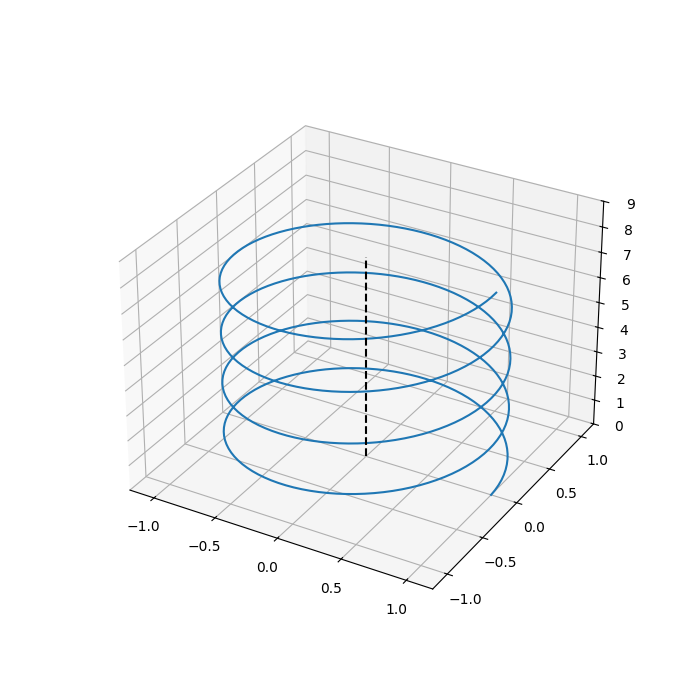

In [25]:
%matplotlib widget

import numpy as np
import matplotlib.pyplot as plt
from matplotlib.animation import FuncAnimation

# Задаем время (
t = np.linspace(0, 8 * np.pi, 400)

# Уравнения винтовой линии (спирали)
x = np.cos(t)
y = np.sin(t)
z = t / np.pi  # Z будет расти от 0 до 8

fig = plt.figure(figsize=(7, 7))
# Указываем, что график будет трехмерным 
ax = fig.add_subplot(111, projection='3d')

# Отрисовываем саму спираль 
ax.plot(x, y, z, label='Траектория')

# Отрисовываем центральную ось Z (черный пунктир)
ax.plot([0, 0], [0, 0],[0, np.max(z)], 'k--')

# Настраиваем границы осей, чтобы график не дергался при анимации
ax.set_xlim([-1.2, 1.2])
ax.set_ylim([-1.2, 1.2])
ax.set_zlim([0, 9])

# Создаем "пустые" точки и линии, которые будем двигать в цикле
red_point, = ax.plot([], [],[], 'ro', markersize=8)      # Красная точка
green_point, = ax.plot([], [],[], 'go', markersize=5)    # Зеленая точка на оси
line_connect, = ax.plot([], [],[], 'k:')                 # Черная точечная линия между ними

def update(i):
    # Обновляем КРАСНУЮ точку (на спирали)
    red_point.set_data([x[i]], [y[i]])
    red_point.set_3d_properties([z[i]])
    
    # Обновляем ЗЕЛЕНУЮ точку (на оси Z, x=0, y=0)
    green_point.set_data([0], [0])
    green_point.set_3d_properties([z[i]])
    
    # Обновляем ЛИНИЮ между ними (от (0,0) до (x,y))
    line_connect.set_data([0, x[i]], [0, y[i]])
    line_connect.set_3d_properties([z[i], z[i]])
    
    return red_point, green_point, line_connect

ani = FuncAnimation(fig, update, frames=len(t), interval=20, blit=False)

plt.show()